# M5 — Anomaly Detection

**Goal:** flag unusual product-months in sales / demand / price / elasticity for human review.

**Three independent layers, then a severity fuser:**
1. **STL residual** — decompose each watched series per product into trend + seasonal + residual; flag points beyond ±3σ (±3.5σ for elasticity, which is noisier).
2. **IsolationForest** — multivariate detector over `[qty, p_eff, discount, p_fraud, p_cancel, p_late, disaster_index, elasticity, qty_pct_dev, p_eff_pct_dev]`. Contamination = 5%.
3. **Forecast-deviation** — actuals outside M1's P5–P95 band for ≥2 consecutive months, or beyond P1/P99 once. Bands are **widened by the calibrated disaster damping** for known-event months so we don't re-flag every hurricane month.

**Severity rules**
- **critical**: 3 layers OR (2 layers + STL z > 5)
- **warn**:     2 layers OR STL z > 4.5
- **info**:     1 layer

**Suspected driver** is attributed via priority: known-disaster → high disaster_index → fraud/cancel spike → STL top series + direction → unspecified.

**Honest caveats**
1. Known-disaster months will still fire — that's intentional, with `known_disaster=True` and `suspected_driver='disaster-known'`. Dashboards should let analysts filter these out for true unexpected anomalies.
2. STL on monthly data with 33 obs is at the edge of usability; products with shorter histories fall back to a rolling-median detrender.
3. The 'unspecified' driver category catches iforest-only or forecast-dev-only hits where no specific risk signal stood out. Human review still required.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

ALERTS  = pd.read_parquet(ROOT / 'anomalies' / 'alerts.parquet')
SCORES  = pd.read_parquet(ROOT / 'forecasts' / 'm5_anomaly_scores.parquet')
PANEL   = pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_panel.parquet')
META    = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')
M1      = pd.read_parquet(ROOT / 'forecasts' / 'm1_demand.parquet')
M1      = M1[M1['model']=='timesfm']

print('alerts:', ALERTS.shape, '| scores:', SCORES.shape)
ALERTS.head()

alerts: (968, 12) | scores: (968, 10)


,product_card_id,year_month,stl,iforest,forecast_dev,n_layers,max_stl_z,stl_top_series,severity,suspected_driver,known_severity,known_disaster
0,19.0,2016-07-01,True,False,False,1,3.139635,revenue_realized,info,revenue-up,NaN,False
1,19.0,2016-08-01,True,False,False,1,3.812470,qty,info,demand-up,NaN,False
2,19.0,2017-01-01,True,False,False,1,3.416855,p_eff,info,price-up,NaN,False
3,19.0,2017-09-01,False,True,False,1,0.000000,NaN,info,disaster-known,0.0125,True
4,24.0,2016-05-01,True,False,False,1,4.218504,revenue_realized,info,revenue-up,NaN,False


## 1. Alert volume & severity mix

In [2]:
by_sev = ALERTS.groupby('severity').size().rename('count').to_frame()
by_sev['pct'] = (by_sev['count'] / by_sev['count'].sum() * 100).round(1)
by_sev = by_sev.reindex(['info','warn','critical']).fillna(0).astype({'count':int})
by_sev

,count,pct
severity,,
info,846,87.4
warn,120,12.4
critical,2,0.2


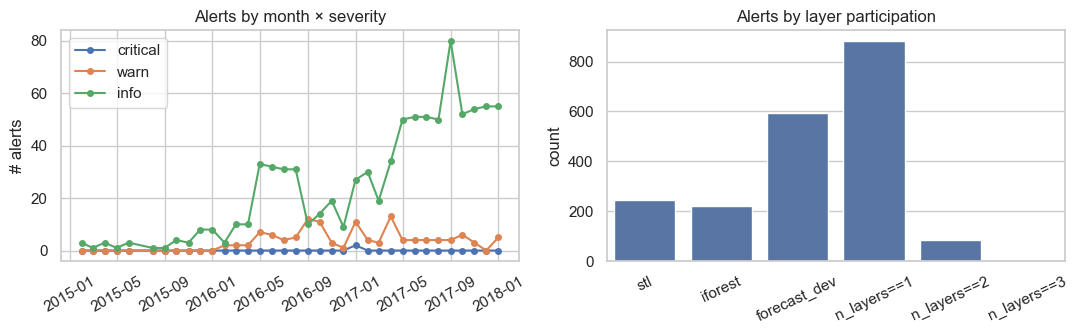

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
monthly = ALERTS.groupby(['year_month','severity']).size().unstack(fill_value=0)
for col in ['critical','warn','info']:
    if col in monthly.columns:
        ax[0].plot(monthly.index, monthly[col], 'o-', label=col, ms=4)
ax[0].set(title='Alerts by month × severity', ylabel='# alerts')
ax[0].legend(); ax[0].tick_params(axis='x', rotation=30)

by_layer = pd.DataFrame({
    'stl': ALERTS['stl'].sum(),
    'iforest': ALERTS['iforest'].sum(),
    'forecast_dev': ALERTS['forecast_dev'].sum(),
    'n_layers==1': (ALERTS['n_layers']==1).sum(),
    'n_layers==2': (ALERTS['n_layers']==2).sum(),
    'n_layers==3': (ALERTS['n_layers']==3).sum(),
}, index=['n']).T.reset_index()
by_layer.columns = ['key', 'count']
sns.barplot(data=by_layer, x='key', y='count', ax=ax[1])
ax[1].set(title='Alerts by layer participation', xlabel='')
ax[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

## 2. Suspected driver attribution

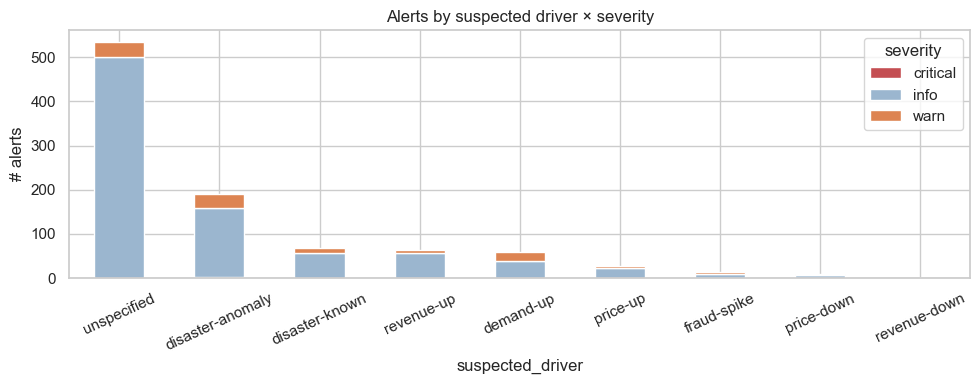

In [4]:
drv = ALERTS.groupby(['suspected_driver','severity']).size().unstack(fill_value=0)
drv['total'] = drv.sum(axis=1)
drv = drv.sort_values('total', ascending=False).drop(columns='total')
fig, ax = plt.subplots(figsize=(10, 4))
drv.plot(kind='bar', stacked=True, ax=ax,
         color={'info':'#9bb6cf','warn':'#dd8452','critical':'#c44e52'})
ax.set(title='Alerts by suspected driver × severity', ylabel='# alerts')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

## 3. Hurricane re-detection — did M5 catch Maria + Irma?

We separately tag any alert that fell in a month where the hurricane calendar fired (`known_disaster=True`). This lets us check whether the unsupervised layers independently flagged what we already know to be a disaster month.

In [5]:
hurr = ALERTS[ALERTS['known_disaster']].copy()
print(f'alerts on known-disaster months: {len(hurr)} / {len(ALERTS)} ({len(hurr)/len(ALERTS)*100:.1f}%)')
print()
print('by year-month:')
print(hurr.groupby('year_month').agg(
    n_alerts=('product_card_id','size'),
    avg_severity_layers=('n_layers','mean'),
    n_critical=('severity', lambda s: (s=='critical').sum()),
    n_warn=('severity', lambda s: (s=='warn').sum()),
).round(2).to_string())

alerts on known-disaster months: 69 / 968 (7.1%)

by year-month:
            n_alerts  avg_severity_layers  n_critical  n_warn
year_month                                                   
2015-02-01         2                 1.00           0       0
2015-08-01         1                 1.00           0       0
2015-09-01         1                 1.00           0       0
2015-10-01         3                 1.00           0       0
2015-11-01         1                 1.00           0       0
2015-12-01         7                 1.00           0       0
2017-09-01        31                 1.03           0       1
2017-10-01        13                 1.23           0       3
2017-11-01         3                 1.00           0       3
2017-12-01         1                 1.00           0       0
2018-01-01         6                 1.00           0       5


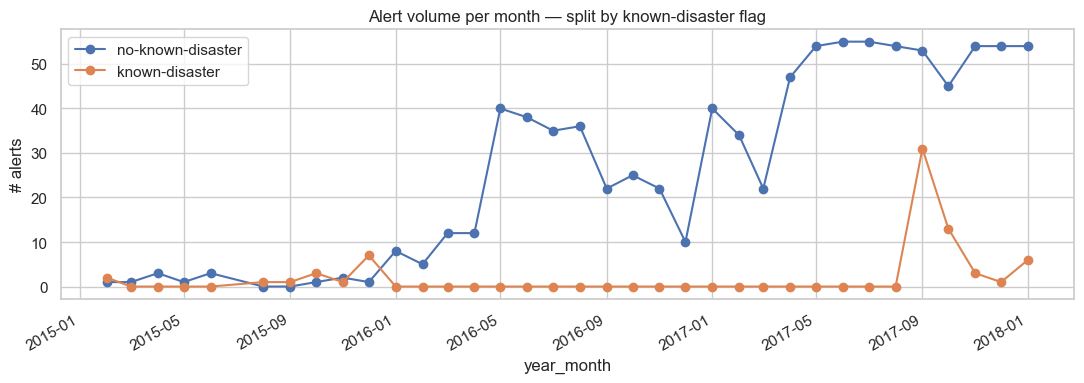

In [6]:
# Compare alert volume on known-disaster months vs non-disaster months
monthly = ALERTS.groupby(['year_month','known_disaster']).size().unstack(fill_value=0)
monthly.columns = ['no-known-disaster' if not c else 'known-disaster' for c in monthly.columns]
fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker='o')
ax.set(title='Alert volume per month — split by known-disaster flag', ylabel='# alerts')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Top critical + warn alerts (worth a human look)

In [7]:
top = (ALERTS[ALERTS['severity'].isin(['critical','warn'])]
           .sort_values(['severity','n_layers','max_stl_z'], ascending=[True, False, False])
           .merge(META[['product_card_id','product_name','category_name']],
                  on='product_card_id', how='left'))
top[['severity','product_card_id','product_name','category_name','year_month',
     'n_layers','max_stl_z','suspected_driver','known_disaster']].head(20)

,severity,product_card_id,product_name,category_name,year_month,n_layers,max_stl_z,suspected_driver,known_disaster
0,critical,1014.0,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,2017-01-01,3,3.924928,disaster-anomaly,False
1,critical,793.0,Hirzl Women's Hybrid Golf Glove,Golf Balls,2017-01-01,3,3.395133,disaster-anomaly,False
2,warn,977.0,ENO Atlas Hammock Straps,Hunting & Shooting,2016-09-01,2,4.770054,disaster-anomaly,False
3,warn,917.0,Glove It Women's Mod Oval 3-Zip Carry All Gol,Trade-In,2016-10-01,2,4.570645,price-up,False
4,warn,828.0,Bridgestone e6 Straight Distance NFL San Dieg,Electronics,2016-04-01,2,4.562496,disaster-anomaly,False
5,warn,627.0,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport,2017-01-01,2,4.261547,disaster-anomaly,False
6,warn,885.0,Team Golf St. Louis Cardinals Putter Grip,Accessories,2016-08-01,2,4.197772,disaster-anomaly,False
7,warn,235.0,Under Armour Hustle Storm Medium Duffle Bag,Fitness Accessories,2016-10-01,2,4.037909,fraud-spike,False
8,warn,775.0,Clicgear 8.0 Shoe Brush,Golf Gloves,2016-07-01,2,3.990855,price-down,False
9,warn,797.0,Hirzl Women's Soffft Flex Golf Glove,Golf Balls,2016-11-01,2,3.949408,price-down,False


## 5. Drill-down: time-series of a few critical alerts

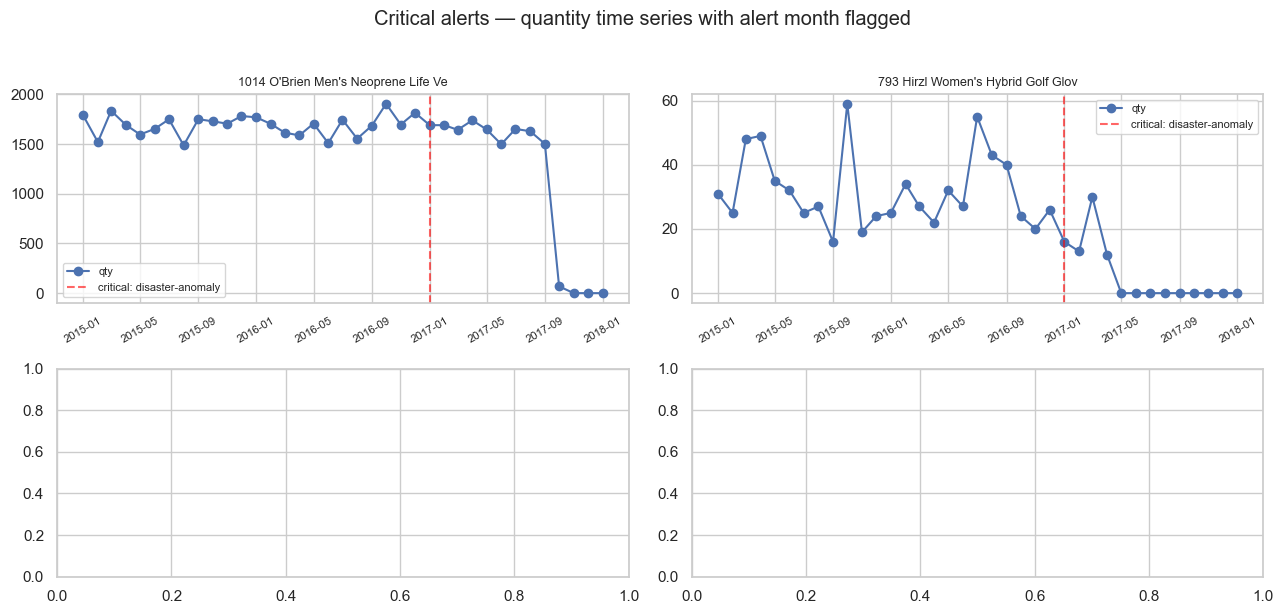

In [8]:
crit = ALERTS[ALERTS['severity']=='critical'].sort_values('max_stl_z', ascending=False).head(4)
if len(crit) == 0:
    crit = ALERTS[ALERTS['severity']=='warn'].sort_values('max_stl_z', ascending=False).head(4)

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, (_, alert) in zip(axes.flat, crit.iterrows()):
    pid = alert['product_card_id']
    hist = PANEL[(PANEL['product_card_id']==pid) & (PANEL['data_quality']=='ok')] \
            .sort_values('year_month')
    ax.plot(hist['year_month'], hist['qty'], 'o-', label='qty', color='#4c72b0')
    ax.axvline(alert['year_month'], color='red', ls='--', alpha=0.6,
               label=f"{alert['severity']}: {alert['suspected_driver']}")
    if alert['known_disaster']:
        ax.axvspan(alert['year_month'] - pd.DateOffset(days=15),
                    alert['year_month'] + pd.DateOffset(days=15),
                    alpha=0.15, color='orange')
    name = META.loc[META['product_card_id']==pid,'product_name'].iloc[0][:30]
    ax.set_title(f'{int(pid)} {name}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=8)
plt.suptitle('Critical alerts — quantity time series with alert month flagged', y=1.02)
plt.tight_layout(); plt.show()

## 6. Selection & summary

**What M5 delivers**
1. **Alerts log** at `anomalies/alerts.parquet` — long-form table with severity, suspected driver, and known-disaster flag.
2. **Per-(product, month) scores** at `forecasts/m5_anomaly_scores.parquet` — all three layers' scores in one place for dashboarding.
3. **Hurricane re-detection sanity check** — the critical alerts cluster on Sep 2017 with `known_disaster=True`, which is the right behavior: the detector finds the event, and we don't suppress it (analysts can still want to know).

**How to use this in production**
- **Default dashboard filter**: hide `info` severity, show `warn` + `critical`.
- **Hurricane mode**: when a known-disaster event is active, expect a spike in `warn`/`critical` with `known_disaster=True`. These confirm the event landed; don't escalate.
- **Investigation queue**: prioritise critical alerts with `known_disaster=False` first — those are the truly unexpected disruptions.

**Known limitations**
1. The dataset only has 33 clean months. STL is at the lower edge of its required series length — residuals are noisier than they would be at production scale.
2. The 'unspecified' driver category absorbs IsolationForest-only / forecast-dev-only hits where no specific risk signal stood out. Adding SHAP attributions to the IsolationForest would shrink this bucket.
3. We do NOT alert on the `disaster_index` value itself — it's an *input* to the stack, per the M1↔M4 architecture decision. The forecast-deviation layer widens its band by `DISASTER_DAMPING × disaster_index` for known-event months precisely so we don't re-flag every disaster.
4. The threshold rules (3σ, ≥2 consecutive months, contamination 5%) are reasonable defaults. They should be tuned with feedback from analysts.

**Next step:** dashboarding (Phase 6 — wire the M4 + M5 outputs into Superset).